# Radius-2 nonlinear fate-fraction benchmark

**Role:** Dedicated training and benchmarking experiment.

Test whether explicit nonlinear responses to neighborhood composition close the predictive gap between the additive fate spline and a depth-2 FiLM GNN. Every candidate uses exclusive center identity, the fraction of each identity (including Unassigned) in exact-hop rings 1 and 2, and organoid cell count N. No ring sizes, absolute neighbor counts, geometry predictors or extra graph motifs enter the candidate models. The saved organoid baseline is retained as the common target residualization, not added as a new candidate input.

The reference run supplies the exact cohort, target cleanup, baselines and five outer folds. Its zero-masking depth-2 FiLM checkpoints are evaluated without retraining. Candidate penalties and fraction-pair screening use an inner organoid holdout within each outer-training fold; outer validation is reserved for reporting. All candidate outputs remain explicit sums with cubic-spline coefficients in log N. Polynomial abundance terms allow nonlinear fraction responses, and a small screened set of fraction products tests additional composition interactions. This notebook compares prediction quality; coefficient interpretation is intentionally deferred.

A timestamped run saves portable models, transforms, baselines, exact splits, inner membership, selected pairs, every penalty trial, per-organoid validation MSE and benchmark figures. Running all cells trains a fresh run; set `RUN_TRAINING=False` and `SAVED_RUN` to an existing output to redisplay completed results.

In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src/models/gnn.py').is_file())  # Repository root.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
ROOT = PROJECT_ROOT  # Resolve data and saved-run paths relative to this directory.

## Settings

Only candidate-model and benchmark settings are chosen here. Dataset filters, timepoints, cleaned targets, exclusive identities, outer folds and baseline models come from the reference. All five folds are evaluated at radius/depth 2. The full candidate grid is fixed before inspecting its outer validation results. The old spline checkpoint is included as a historical radius-2 comparator; it is not retrained.

In [2]:
import copy
import gc
import hashlib
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display
from src.artifacts.runs import AnalysisRun, select_depth_records
from src.artifacts.bundle import save_bundle, load_bundle, graph_membership
from src.artifacts.paths import training_run_path
from src.artifacts.provenance import workflow_fingerprint
from src.data.marker_exclusivity import exclusive_markers, EXCLUSIVITY_RULES
from src.data.target_transforms import IdentityTransform
from src.training.spline_fit import graph_samples, fit_fraction_spline
from src.training.progress import TrainingProgress
from src.analysis.metrics.evaluation import prediction_table, regional_mse, organoid_mse_summary
from src.analysis.spatial.regions import graph_regions
from threadpoolctl import threadpool_limits

# Execution and output
RUN_TRAINING = True  # Train a fresh run; False only reads SAVED_RUN for figures.
SAVED_RUN = None  # Completed run path when RUN_TRAINING=False.
SHOW_PROGRESS = True  # Display current fold/model and completed-task counters.
REFERENCE_RUN = 'training_results/fate_masking_training/Ndependent_20260922_115100'  # Exact cohort, folds, baselines and zero-masking FiLM.
OLD_SPLINE_RUN = 'training_results/fate_spline_training/exclusive_pairwise_20260924_142840'  # Previously fitted linear radius-2 comparator.

SETTINGS = dict(
    # Candidate architecture and fate representation
    tag='nonlinear_fractions',  # Purpose label in the timestamped output folder.
    radius=2,  # Rings 1 and 2 only; benchmark reference also has depth 2.
    n_splines=5,  # Cubic-spline basis functions over log N.
    exclusive_markers=True,  # Require saved exclusive fates, with Unassigned as an identity.
    residualize=True,  # Reuse the reference's saved baseline for physical residual targets.
    target_scaling='identity',  # Explicit additive predictions in physical curvature units.
    variants=[
        dict(name='linear_tuned', fraction_degree=1, center_nonlinear=True, n_interactions=0),  # Broader regularization search only.
        dict(name='quadratic_shared', fraction_degree=2, center_nonlinear=False, n_interactions=0),  # Shared nonlinear abundance terms.
        dict(name='quadratic_center', fraction_degree=2, center_nonlinear=True, n_interactions=0),  # Center-dependent nonlinear abundance terms.
        dict(name='cubic_center', fraction_degree=3, center_nonlinear=True, n_interactions=0),  # More flexible abundance curves.
        dict(name='cubic_interactions', fraction_degree=3, center_nonlinear=True, n_interactions=8),  # Eight training-screened fraction pairs, within or across rings.
    ],

    # Inner selection: never use the outer validation fold for fitting
    smoothness_grid=[1e-5, 1e-3, .01],  # N-spline second-difference penalties.
    ridge_grid=[1e-6, 1e-5, 1e-4, 1e-3],  # Include much weaker shrinkage than the original fit.
    extension_multipliers=[1., 10.],  # Extra shrinkage for extensions; for linear-only, center-dependent terms.
    inner_fraction=.2,  # Organoid fraction held out inside each saved training fold.
    matched_fit_check=True,  # Also fit a cubic model on exactly the FiLM weight-fitting cohort.
    seeds=[42],  # Inner membership seed; fitting itself is deterministic.
    blas_threads=2,  # Limit CPU threads and memory pressure for dense spline fitting.

    # Benchmark predictor selection; does not determine the saved data splits
    reference_model='film',  # Already-trained predictor family.
    reference_depth=2,  # Match candidate radius exactly.
    reference_width=128,  # Identify the saved FiLM architecture.
    reference_seed=42,  # Identify its saved checkpoints.
    reference_rate=0.,  # Intact, zero-masking control model.
)

# Regional evaluation only: not inputs to fitting or pair selection
REGION_SETTINGS = dict(
    crypt_max=.8,  # Crypt interior ends at normalized crypt distance 0.8.
    neck_max=1.2,  # Profile-qualified neck band ends at 1.2.
    neck_config=dict(
        minimum_crypt_cells=10,  # Minimum detected crypt support.
        minimum_relative_depth=.05,  # Relative circumference trough depth.
        plateau_max_range=.10,  # Allowed flat-neck circumference variation.
        plateau_max_slope=.25,  # Allowed flat-neck profile slope.
        plateau_exit_rise=.10,  # Required rise beyond a plateau.
    ),
)
REGIONS = ['total', 'crypt', 'neck', 'villus']  # Panels to display; other region rows are also saved.
N_BINS = [0, 150, 300, 550, 800, np.inf]  # Descriptive validation bins; never used to fit the models.

## Restore the cohort and verify the comparison

Resolve one zero-masking FiLM checkpoint per saved fold. Check the original spline comparator uses the same outer membership. Only one fold's prepared data are held at a time to keep memory use modest. Raw organoid graphs are used for source-derived region annotations and saving the cohort; models receive only exclusive fates and N. All benchmark targets are reconstructed with their saved transforms and baseline offsets before comparison.

In [3]:
if RUN_TRAINING:
    if len(SETTINGS['seeds']) != 1:
        raise ValueError('This dedicated benchmark uses one inner-split seed; specify exactly one seed.')
    if SETTINGS['radius'] != 2 or SETTINGS['reference_depth'] != 2:
        raise ValueError('This experiment is a matched radius/depth-2 benchmark.')
    reference = AnalysisRun(ROOT / REFERENCE_RUN)
    ref_records = select_depth_records(reference, SETTINGS['reference_depth'],
        model_name=SETTINGS['reference_model'], hidden_dim=SETTINGS['reference_width'],
        seeds=[SETTINGS['reference_seed']], rate=SETTINGS['reference_rate'])
    membership = json.loads((reference.directory/'splits.json').read_text())
    old_run = AnalysisRun(ROOT / OLD_SPLINE_RUN)
    if membership != json.loads((old_run.directory/'splits.json').read_text()):
        raise ValueError('Old spline and FiLM memberships differ.')
    old_records = select_depth_records(old_run, 2, model_name='spline_pairwise', seeds=[42])
    if not reference.settings.get('exclusive_markers'):
        raise ValueError('Reference must already use exclusive fates.')
    cohort_data = load_bundle(reference.directory/'cohort')
    raw_graphs = cohort_data['raw_graphs']
    marker_names = list(cohort_data['all_marker_names'])
    for graph in raw_graphs.values():
        graph.x = torch.as_tensor(exclusive_markers(graph.x.cpu().numpy(), marker_names), dtype=graph.x.dtype)
    for key in ('dataset','target_indices','timepoints','blacklist','sphericity_max','complexity_min',
                'interpolate_outliers','outlier_quantiles','n_folds','val_fraction','split_seed',
                'baseline_features','baseline_hidden_dim','baseline_max_epochs','baseline_patience','batch_size','num_workers'):
        if key in reference.settings:
            SETTINGS[key] = reference.settings[key]
    SETTINGS.update(reference_run=str(reference.directory), old_spline_run=str(old_run.directory),
        global_features=[], size_input='full_num_cells', depths=[2],
        baseline_source='copied from reference; never retrained')
    RUN_DIR = training_run_path(ROOT, 'fate_fraction_benchmark', SETTINGS['tag'])
    cohort = pd.DataFrame([dict(organoid_str=k,n_cells=len(g.x),timepoint=str(g.meta.get('timepoint','unknown'))) for k,g in raw_graphs.items()])
    display(pd.DataFrame([dict(fold=s['fold'],training=len(s['train']),validation=len(s['validation'])) for s in membership]))
    print(f'{len(SETTINGS["variants"])} candidates × {len(membership)} folds; every predictor radius/depth = 2.')
    print('Output:',RUN_DIR)
else:
    if SAVED_RUN is None:
        raise ValueError('Set SAVED_RUN to a completed benchmark directory.')
    RUN_DIR = ROOT / SAVED_RUN
    SETTINGS = json.loads((RUN_DIR/'settings.json').read_text())
    REGION_SETTINGS = json.loads((RUN_DIR/'region_settings.json').read_text())

5 candidates × 5 folds; every predictor radius/depth = 2.
Output: /home/fmoller/Projects/LearningOrganoids/GraphNN/training_results/fate_fraction_benchmark/nonlinear_fractions_20260924_153659


,fold,training,validation
0,0,936,234
1,1,936,234
2,2,936,234
3,3,936,234
4,4,936,234


## Prepare immutable artifacts and region annotations

Copy the cohort, exact split manifest, baseline provenance and all settings into the new run. Region labels come directly from the original graphs, segmentation metadata and circumference profiles. Region annotations are never used for training or interaction screening. A node outside a reliably classified crypt/neck remains in its own region rather than being silently assigned to a neck.

In [4]:
if RUN_TRAINING:
    RUN_DIR.mkdir(parents=True,exist_ok=False)
    (RUN_DIR/'settings.json').write_text(json.dumps(SETTINGS,indent=2))
    (RUN_DIR/'splits.json').write_text(json.dumps(membership,indent=2))
    (RUN_DIR/'region_settings.json').write_text(json.dumps(REGION_SETTINGS,indent=2))
    (RUN_DIR/'reference_settings.json').write_text(json.dumps(reference.settings,indent=2))
    (RUN_DIR/'exclusivity_rules.json').write_text(json.dumps(EXCLUSIVITY_RULES,indent=2))
    cohort.to_csv(RUN_DIR/'cohort.csv',index=False)
    provenance = dict(code_sha256=workflow_fingerprint(ROOT/'experiments/training/fate_fraction_benchmark.ipynb'))
    (RUN_DIR/'provenance.json').write_text(json.dumps(provenance,indent=2))
    source_paths = ['settings.json','splits.json','cohort/manifest.json']
    source_paths += [f'{v}/manifest.json' for v in set(ref_records.input_bundle)|set(ref_records.bundle)]
    source_hashes = {p:hashlib.sha256((reference.directory/p).read_bytes()).hexdigest() for p in source_paths}
    (RUN_DIR/'reference_artifacts.json').write_text(json.dumps(dict(run=str(reference.directory),sha256=source_hashes),indent=2))
    save_bundle(RUN_DIR/'cohort',dict(raw_graphs=raw_graphs,all_marker_names=marker_names,
        settings=SETTINGS,outlier_info=cohort_data.get('outlier_info')),splits=membership,provenance=provenance)
    annotations = {}
    for i,(oid,g) in enumerate(raw_graphs.items()):
        annotations[oid] = graph_regions(g,ROOT/'training_data'/SETTINGS['dataset'],**REGION_SETTINGS)
        if (i+1)%200 == 0:
            print(f'Regions: {i+1}/{len(raw_graphs)} organoids',flush=True)
    pd.concat(annotations.values(),ignore_index=True).to_csv(RUN_DIR/'node_regions.csv.gz',index=False)
    del cohort_data
    gc.collect()

Regions: 200/1170 organoids
Regions: 400/1170 organoids
Regions: 600/1170 organoids
Regions: 800/1170 organoids
Regions: 1000/1170 organoids


## Fit the candidate grid and benchmark each saved fold

Training minimizes mean per-organoid physical residual MSE. Weaker penalties are tested first on the linear model. Quadratic and cubic fraction terms then add shared or center-dependent abundance responses. The final candidate screens eight fraction-pair products (within or across rings) using only inner-training residual associations. Screening is repeated using all outer-training organoids for the final refit. This exploratory selection does not establish biological interactions.

New features are projected away from the lower-order local design using equal-organoid training moments, then scaled to a common RMS. The projections and their inverse coefficient mapping are saved, so predictions can still be decomposed exactly into explicit functions. All coefficients vary smoothly with log N, with N clamped outside the training range. There is no nonlinear output head.

Each candidate's penalties are chosen on the same inner organoid split. A separate **inner-selected** benchmark also chooses the candidate family using that inner MSE, before looking at outer validation. The previously trained spline and FiLM are evaluated on the same reconstructed targets. The progress panel shows the active candidate/fold; checkpoint, trial and score tables are saved after every fit. No GNN is trained again.

In [5]:
def score_prediction(name,fold,sample,prediction,baseline_error):
    """Notebook-specific total/regional reporting on a fixed held-out organoid."""
    error = (prediction-sample['y'])**2
    region = annotations[sample['organoid_str']].sort_values('node')
    if not np.array_equal(region.node.to_numpy(),np.arange(len(error))):
        raise ValueError('Region annotations are not aligned with graph nodes.')
    rows = [dict(name=name,fold=fold,organoid_str=sample['organoid_str'],region='total',
                 mse=float(error.mean()),baseline_mse=float(baseline_error.mean()),n_cells=sample['N'])]
    labels = region.region.to_numpy()
    for label in np.unique(labels):
        take = labels == label
        rows.append(dict(name=name,fold=fold,organoid_str=sample['organoid_str'],region=label,
            mse=float(error[take].mean()),baseline_mse=float(baseline_error[take].mean()),n_cells=int(take.sum())))
    return rows

if RUN_TRAINING:
    torch.set_num_threads(SETTINGS['blas_threads'])
    records, scores, trials_all, audits, selections = [], [], [], [], []
    count_cache = {}
    start_time = time.perf_counter()
    with threadpool_limits(limits=SETTINGS['blas_threads']), TrainingProgress(
            len(SETTINGS['variants'])*len(membership),show=SHOW_PROGRESS,
            log_path=RUN_DIR/'training_progress.csv') as progress:
        for split in membership:
            fold = split['fold']
            row = ref_records[ref_records.fold == fold].iloc[0].to_dict()
            print(f'Fold {fold}: restore exact data and evaluate saved FiLM',flush=True)
            source = load_bundle(reference.directory/row['input_bundle'])
            if graph_membership(train=source['groups']['train'],validation=source['groups']['val']) != {k:split[k] for k in ('train','validation')}:
                raise ValueError('Reference inputs differ from saved membership.')
            if source['marker_names'] != marker_names or not source['residualized'] or source['baseline'] is None:
                raise ValueError('Reference fate order or baseline residualization is incompatible.')
            ref_model = load_bundle(reference.directory/row['bundle'])['model']
            ref_predictions = prediction_table(dict(**source,model=ref_model),device='cpu',batch_size=4)
            ref_by_org = {str(oid):frame.sort_values('node') for oid,frame in ref_predictions.groupby('organoid_str',sort=False)}
            del ref_model,ref_predictions
            offsets = {}
            for role,group in source['groups'].items():
                for g in group:
                    oid = str(g.organoid_str)
                    if g.x.shape[1] > len(marker_names) and torch.any(g.x[:,len(marker_names):] != 0):
                        raise ValueError('Expected fully observed reference inputs.')
                    original = g.x[:,:len(marker_names)].cpu().numpy()
                    exclusive = exclusive_markers(original,marker_names)
                    if not np.array_equal(original,exclusive):
                        raise ValueError('Reference fates are not already exclusive.')
                    physical = np.asarray(source['transform'].inverse(g.y.cpu().numpy())).reshape(-1)+np.asarray(source['baseline_offsets'][oid]).reshape(-1)
                    baseline = np.asarray(source['baseline_predictions'][oid]).reshape(-1)
                    offsets[oid] = baseline.copy()
                    g.x = torch.tensor(exclusive,dtype=g.x.dtype)
                    g.y = torch.tensor(physical-baseline,dtype=torch.float64)
                    g.full_num_cells = float(len(g.x))
                    if 'global_feat' in g:
                        del g.global_feat
                    if role == 'val':
                        np.testing.assert_allclose(physical,ref_by_org[oid].y_true,atol=1e-10,rtol=1e-6)
            prepared = dict(source,transform=IdentityTransform().fit(source['groups']['train']),
                baseline_offsets=offsets,global_features=[],source_run=str(reference.directory),source_input_bundle=row['input_bundle'])
            input_bundle = f'inputs/fold_{fold}_all_intact'
            save_bundle(RUN_DIR/input_bundle,prepared,splits=split,provenance=provenance)
            samples = {}
            for role,group in source['groups'].items():
                samples[role] = []
                for g in group:
                    oid = str(g.organoid_str)
                    if oid not in count_cache:
                        entry = graph_samples([g],2)[0]
                        count_cache[oid] = {k:v for k,v in entry.items() if k != 'y'}
                    samples[role].append(dict(**count_cache[oid],y=g.y.numpy().reshape(-1)))
            old_row = old_records[old_records.fold == fold].iloc[0].to_dict()
            if old_run.settings['reference_run'] != str(reference.directory) or not old_run.settings['residualize']:
                raise ValueError('Historical spline has a different reference or target scale.')
            old_model = load_bundle(old_run.directory/old_row['bundle'])['model']
            old_saved = pd.read_csv(old_run.directory/'validation_mse.csv')
            old_saved = old_saved[old_saved.key == old_row['key']].set_index('organoid_str')
            for s in samples['val']:
                oid = s['organoid_str']
                baseline_error = s['y']**2
                film_pred = ref_by_org[oid].y_pred.to_numpy()-offsets[oid]
                scores.extend(score_prediction('FiLM',fold,s,film_pred,baseline_error))
                old_pred = old_model.predict_sample(s)
                np.testing.assert_allclose(np.mean((old_pred-s['y'])**2),old_saved.loc[oid,'mse'],rtol=1e-7,atol=1e-12)
                scores.extend(score_prediction('original_spline',fold,s,old_pred,baseline_error))
            audits.append(dict(fold=fold,reference_key=row['key'],matched_membership=True,matched_targets=True,
                matched_exclusive_fates=True,old_mse_reproduced=True,reference_depth=2,candidate_radius=2))
            (RUN_DIR/'comparison_audit.json').write_text(json.dumps(audits,indent=2))
            del old_model,ref_by_org,source,prepared
            gc.collect()
            fold_metrics = []
            for variant in SETTINGS['variants']:
                name = variant['name']
                print(f'Fold {fold}: {name}',flush=True)
                with progress.task(model=name,depth=2,fold=fold,seed=SETTINGS['seeds'][0]):
                    def stage(message):
                        progress.stage(message)
                        print(f'  {message}',flush=True)
                    model,metrics,trials = fit_fraction_spline(samples['train'],n_markers=len(marker_names),radius=2,
                        n_splines=SETTINGS['n_splines'],**{k:v for k,v in variant.items() if k != 'name'},
                        smoothness_grid=SETTINGS['smoothness_grid'],ridge_grid=SETTINGS['ridge_grid'],
                        extension_multipliers=SETTINGS['extension_multipliers'],inner_fraction=SETTINGS['inner_fraction'],
                        seed=SETTINGS['seeds'][0],blas_threads=SETTINGS['blas_threads'],callback=stage)
                    key = f'{name}_d2_f{fold}_s{SETTINGS["seeds"][0]}'
                    record = dict(key=key,name=name,depth=2,fold=fold,seed=SETTINGS['seeds'][0],subset='all',signal='intact',
                                  bundle=f'models/{key}',input_bundle=input_bundle)
                    save_bundle(RUN_DIR/record['bundle'],dict(model=model,record=record,metrics=metrics,
                        history=trials.to_dict('list')),splits=split,provenance=provenance)
                    (RUN_DIR/record['bundle']/'fit_settings.json').write_text(json.dumps(metrics,indent=2))
                    for s in samples['val']:
                        scores.extend(score_prediction(name,fold,s,model.predict_sample(s),s['y']**2))
                    records.append(record)
                    fold_metrics.append(dict(name=name,key=key,inner_mse=metrics['best']['inner_mse']))
                    trials_all.append(trials.assign(key=key,name=name,fold=fold))
                    pd.DataFrame(records).to_json(RUN_DIR/'models.json',orient='records',indent=2)
                    pd.DataFrame(scores).to_csv(RUN_DIR/'validation_mse.csv',index=False)
                    pd.concat(trials_all,ignore_index=True).to_csv(RUN_DIR/'penalty_trials.csv',index=False)
                    print(f'  Saved {key}; selected penalties {metrics["best"]}',flush=True)
                    del model
                    gc.collect()
            chosen = min(fold_metrics,key=lambda t:t['inner_mse'])
            selections.append(dict(fold=fold,**chosen))
            scores.extend([dict(s,name='inner_selected') for s in list(scores) if s['fold']==fold and s['name']==chosen['name']])
            (RUN_DIR/'inner_selected_models.json').write_text(json.dumps(selections,indent=2))
            pd.DataFrame(scores).to_csv(RUN_DIR/'validation_mse.csv',index=False)
            del samples
            gc.collect()
    (RUN_DIR/'complete.json').write_text(json.dumps(dict(models=len(records),folds=len(membership),elapsed_seconds=time.perf_counter()-start_time),indent=2))
    # Independent reload through the normal analysis API, not the live model.
    saved = AnalysisRun(RUN_DIR)
    restored = saved.select(records[0]['key'])
    restored_predictions = prediction_table(restored,device='cpu',batch_size=4)
    restored_mse = restored_predictions.groupby('organoid_str').squared_error.mean()
    expected = pd.DataFrame(scores)
    expected = expected[(expected.name==records[0]['name'])&(expected.fold==records[0]['fold'])&(expected.region=='total')].set_index('organoid_str').mse
    np.testing.assert_allclose(restored_mse.sort_index(),expected.sort_index(),rtol=1e-9,atol=1e-12)
    (RUN_DIR/'reload_check.json').write_text(json.dumps(dict(key=records[0]['key'],max_mse_error=float(np.max(np.abs(restored_mse-expected)))),indent=2))
    del restored,saved,raw_graphs,count_cache
    gc.collect()
    print('Completed and verified:',RUN_DIR)

Fold 0: restore exact data and evaluate saved FiLM
Fold 0: linear_tuned
  Configure inner-training fraction basis and selected interactions
  Accumulate inner-training statistics (600 coefficients)
  Inner tuning: smoothness=1e-05, best MSE=0.001886594
  Inner tuning: smoothness=0.001, best MSE=0.001886594
  Inner tuning: smoothness=0.01, best MSE=0.001886594
  Refit selected penalties/basis on all outer-training organoids
  Saved linear_tuned_d2_f0_s42; selected penalties {'smoothness': 1e-05, 'ridge': 0.0001, 'extension_multiplier': 1.0, 'inner_mse': 0.0018865938245568297}
Fold 0: quadratic_shared
  Configure inner-training fraction basis and selected interactions
  Accumulate inner-training statistics (680 coefficients)
  Inner tuning: smoothness=1e-05, best MSE=0.001857603
  Inner tuning: smoothness=0.001, best MSE=0.001857603
  Inner tuning: smoothness=0.01, best MSE=0.001857603
  Refit selected penalties/basis on all outer-training organoids
  Saved quadratic_shared_d2_f0_s42; se

/home/fmoller/miniforge3/envs/organoid-gnn/lib/python3.11/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/home/fmoller/miniforge3/envs/organoid-gnn/lib/python3.11/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/home/fmoller/miniforge3/envs/organoid-gnn/lib/python3.11/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/home/fmoller/miniforge3/envs/organoid-gnn/lib/python3.11/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings

## Check the exact FiLM weight-fitting membership

The saved FiLM procedure reserves 15% of each outer-training fold for early stopping. The main spline candidates above follow the existing spline workflow: tune on an inner split, then refit on all outer-training organoids. To separate that protocol difference from nonlinear fraction modeling, this additional, prespecified cubic candidate uses **only the exact organoids used for FiLM weight optimization**. It uses another internal holdout within that smaller fitting set for its own penalty selection; it does not use FiLM's early-stopping organoids at all. The saved baseline and outer validation organoids stay identical.

This check is deliberately conservative about available fitting labels. It still compares different original training objectives (physical, organoid-weighted MSE here versus the saved transformed Gaussian objective for FiLM). Both protocols are recorded explicitly, and only the candidate's exact fitting membership should be used to describe this secondary fit. Its analysis input bundle retains the shared full outer fold for compatibility; `fit_settings.json` and `matched_fit_membership.json` record the actual smaller fitting subset.

In [21]:
if RUN_TRAINING and SETTINGS.get('matched_fit_check', True):
    source_reference_dir = Path(SETTINGS['reference_run'])
    source_inner = {s['fold']:s for s in json.loads((source_reference_dir/'inner_splits.json').read_text())}
    outer_membership = json.loads((RUN_DIR/'splits.json').read_text())
    records = json.loads((RUN_DIR/'models.json').read_text())
    scores = pd.read_csv(RUN_DIR/'validation_mse.csv').to_dict('records')
    trial_frames = [pd.read_csv(RUN_DIR/'penalty_trials.csv')]
    matched_membership, matched_counts = [], {}
    matched_provenance = dict(code_sha256=workflow_fingerprint(ROOT/'experiments/training/fate_fraction_benchmark.ipynb'),
        purpose='Additional cubic candidate using exactly the FiLM weight-fitting organoids')
    (RUN_DIR/'matched_fit_provenance.json').write_text(json.dumps(matched_provenance,indent=2))
    SETTINGS['matched_fit_check'] = True
    (RUN_DIR/'settings.json').write_text(json.dumps(SETTINGS,indent=2))
    with threadpool_limits(limits=SETTINGS['blas_threads']), TrainingProgress(len(outer_membership),
            show=SHOW_PROGRESS,log_path=RUN_DIR/'matched_fit_progress.csv') as progress:
        for split in outer_membership:
            fold = split['fold']
            saved_inner = source_inner[fold]
            if set(saved_inner['fit']) | set(saved_inner['early_stopping']) != set(split['train']):
                raise ValueError('FiLM fitting/early-stopping IDs do not partition the saved outer training fold.')
            if set(saved_inner['fit']) & set(saved_inner['early_stopping']) or saved_inner['validation'] != split['validation']:
                raise ValueError('Invalid FiLM inner membership.')
            name = 'cubic_matched_fit'
            key = f'{name}_d2_f{fold}_s{SETTINGS["seeds"][0]}'
            if any(r['key']==key for r in records):
                raise ValueError('Matched-fit model already exists; use loading mode to display its results.')
            input_bundle = f'inputs/fold_{fold}_all_intact'
            prepared = load_bundle(RUN_DIR/input_bundle)
            by_id = {str(g.organoid_str):g for g in prepared['groups']['train']}
            roles = dict(train=[by_id[oid] for oid in saved_inner['fit']],val=prepared['groups']['val'])
            samples = {}
            for role,group in roles.items():
                samples[role] = []
                for g in group:
                    oid = str(g.organoid_str)
                    if oid not in matched_counts:
                        entry = graph_samples([g],2)[0]
                        matched_counts[oid] = {k:v for k,v in entry.items() if k != 'y'}
                    samples[role].append(dict(**matched_counts[oid],y=g.y.numpy().reshape(-1)))
            print(f'Matched-fit cubic: fold {fold}, {len(samples["train"])} fitting organoids',flush=True)
            with progress.task(model=name,depth=2,fold=fold,seed=SETTINGS['seeds'][0]):
                def stage(message):
                    progress.stage(message)
                    print(f'  {message}',flush=True)
                model,metrics,trials = fit_fraction_spline(samples['train'],n_markers=len(prepared['marker_names']),
                    radius=2,n_splines=SETTINGS['n_splines'],fraction_degree=3,center_nonlinear=True,n_interactions=0,
                    smoothness_grid=SETTINGS['smoothness_grid'],ridge_grid=SETTINGS['ridge_grid'],
                    extension_multipliers=SETTINGS['extension_multipliers'],inner_fraction=SETTINGS['inner_fraction'],
                    seed=SETTINGS['seeds'][0],blas_threads=SETTINGS['blas_threads'],callback=stage)
                metrics['final_fit_organoids'] = list(saved_inner['fit'])
                metrics['excluded_film_early_stopping_organoids'] = list(saved_inner['early_stopping'])
                metrics['protocol'] = 'Exact FiLM weight-fitting membership; candidate tuning uses a nested holdout within this set; FiLM early-stopping labels not used for candidate tuning or fitting.'
                record = dict(key=key,name=name,depth=2,fold=fold,seed=SETTINGS['seeds'][0],subset='all',signal='intact',
                    bundle=f'models/{key}',input_bundle=input_bundle)
                save_bundle(RUN_DIR/record['bundle'],dict(model=model,record=record,metrics=metrics,history=trials.to_dict('list')),
                    splits=split,provenance=matched_provenance)
                (RUN_DIR/record['bundle']/'fit_settings.json').write_text(json.dumps(metrics,indent=2))
                for s in samples['val']:
                    scores.extend(score_prediction(name,fold,s,model.predict_sample(s),s['y']**2))
                records.append(record)
                matched_membership.append(dict(fold=fold,fit=list(saved_inner['fit']),excluded=list(saved_inner['early_stopping']),validation=split['validation']))
                trial_frames.append(trials.assign(key=key,name=name,fold=fold))
                pd.DataFrame(records).to_json(RUN_DIR/'models.json',orient='records',indent=2)
                pd.DataFrame(scores).to_csv(RUN_DIR/'validation_mse.csv',index=False)
                pd.concat(trial_frames,ignore_index=True).to_csv(RUN_DIR/'penalty_trials.csv',index=False)
                (RUN_DIR/'matched_fit_membership.json').write_text(json.dumps(matched_membership,indent=2))
                print(f'  Saved {key}; selected penalties {metrics["best"]}',flush=True)
            del model,prepared,samples,roles,by_id
            gc.collect()
    complete = json.loads((RUN_DIR/'complete.json').read_text())
    complete.update(models=len(records),matched_fit_models=len(outer_membership),matched_fit_complete=True)
    (RUN_DIR/'complete.json').write_text(json.dumps(complete,indent=2))
    del matched_counts
    gc.collect()


Matched-fit cubic: fold 0, 795 fitting organoids
  Configure inner-training fraction basis and selected interactions
  Accumulate inner-training statistics (1880 coefficients)
  Inner tuning: smoothness=1e-05, best MSE=0.001929134
  Inner tuning: smoothness=0.001, best MSE=0.001928915
  Inner tuning: smoothness=0.01, best MSE=0.001928915
  Refit selected penalties/basis on all outer-training organoids
  Saved cubic_matched_fit_d2_f0_s42; selected penalties {'smoothness': 0.001, 'ridge': 1e-05, 'extension_multiplier': 10.0, 'inner_mse': 0.0019289150795798915}
Matched-fit cubic: fold 1, 795 fitting organoids
  Configure inner-training fraction basis and selected interactions
  Accumulate inner-training statistics (1880 coefficients)
  Inner tuning: smoothness=1e-05, best MSE=0.001871553
  Inner tuning: smoothness=0.001, best MSE=0.001871553
  Inner tuning: smoothness=0.01, best MSE=0.001870533
  Refit selected penalties/basis on all outer-training organoids
  Saved cubic_matched_fit_d2_f

## Validation MSE at matched radius/depth 2

Figure 1 compares total and regional physical-curvature MSE. Every point averages organoid MSEs equally and its error bar is one organoid SEM. Regional panels include only organoids with the corresponding source-derived region label. The baseline is shown separately. The inner-selected row uses the family chosen inside each fold, rather than choosing a family from outer validation performance. These are descriptive uncertainties conditional on fitted models, not independent-fold or retraining confidence intervals.

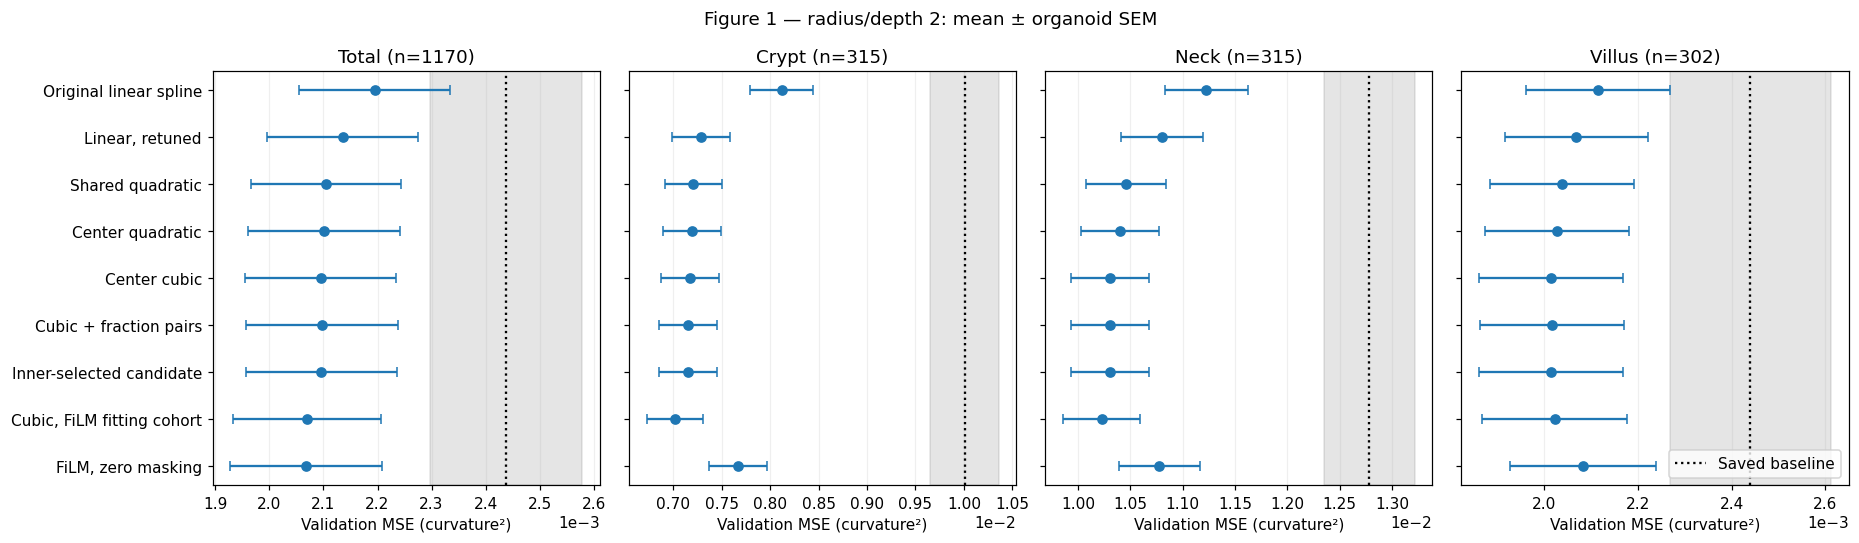

,mean,sem,count
name,,,
original_spline,0.002195,0.000140,1170
linear_tuned,0.002135,0.000139,1170
quadratic_shared,0.002105,0.000140,1170
quadratic_center,0.002101,0.000140,1170
cubic_center,0.002095,0.000140,1170
cubic_interactions,0.002098,0.000140,1170
inner_selected,0.002096,0.000140,1170
cubic_matched_fit,0.002070,0.000137,1170
FiLM,0.002068,0.000140,1170


In [22]:
scores_df = pd.read_csv(RUN_DIR/'validation_mse.csv')
labels = dict(original_spline='Original linear spline',linear_tuned='Linear, retuned',quadratic_shared='Shared quadratic',
    quadratic_center='Center quadratic',cubic_center='Center cubic',cubic_interactions='Cubic + fraction pairs',
    inner_selected='Inner-selected candidate',cubic_matched_fit='Cubic, FiLM fitting cohort',FiLM='FiLM, zero masking')
order = list(labels)
summary = organoid_mse_summary(scores_df,['name','region'])
summary.to_csv(RUN_DIR/'mse_summary.csv',index=False)
fig,axes = plt.subplots(1,len(REGIONS),figsize=(17,5),sharey=True)
for ax,region in zip(axes,REGIONS):
    part = summary[summary.region==region].set_index('name').reindex(order)
    ax.errorbar(part['mean'],np.arange(len(order)),xerr=part['sem'],fmt='o',capsize=3)
    base_rows = scores_df[(scores_df.name=='FiLM')&(scores_df.region==region)]
    base = organoid_mse_summary(base_rows,value='baseline_mse').iloc[0]
    ax.axvline(base['mean'],ls=':',color='black',label='Saved baseline')
    ax.axvspan(base['mean']-base['sem'],base['mean']+base['sem'],alpha=.1,color='black')
    ax.set(title=f'{region.capitalize()} (n={int(part.loc["FiLM","count"])})',xlabel='Validation MSE (curvature²)')
    ax.ticklabel_format(axis='x',style='sci',scilimits=(-2,2))
    ax.grid(axis='x',alpha=.2)
axes[0].set_yticks(np.arange(len(order)),[labels[n] for n in order])
axes[0].invert_yaxis()
axes[-1].legend(loc='lower right')
fig.suptitle('Figure 1 — radius/depth 2: mean ± organoid SEM')
fig.tight_layout()
fig.savefig(RUN_DIR/'01_validation_mse.png',dpi=170,bbox_inches='tight')
plt.show()
display(summary[summary.region=='total'][['name','mean','sem','count']].set_index('name').reindex(order))

## Paired differences from FiLM and consistency across folds

Figure 2 pairs each candidate with FiLM on exactly the same validation organoids. Negative differences favor the candidate. Error bars are one SEM of paired organoid differences, and small points show each fold mean. The percentages divide the paired mean difference by the mean reference MSE in that region; they are not averages of noisy per-organoid MSE ratios. The figure is a benchmark, not a significance test or a coefficient interpretation.

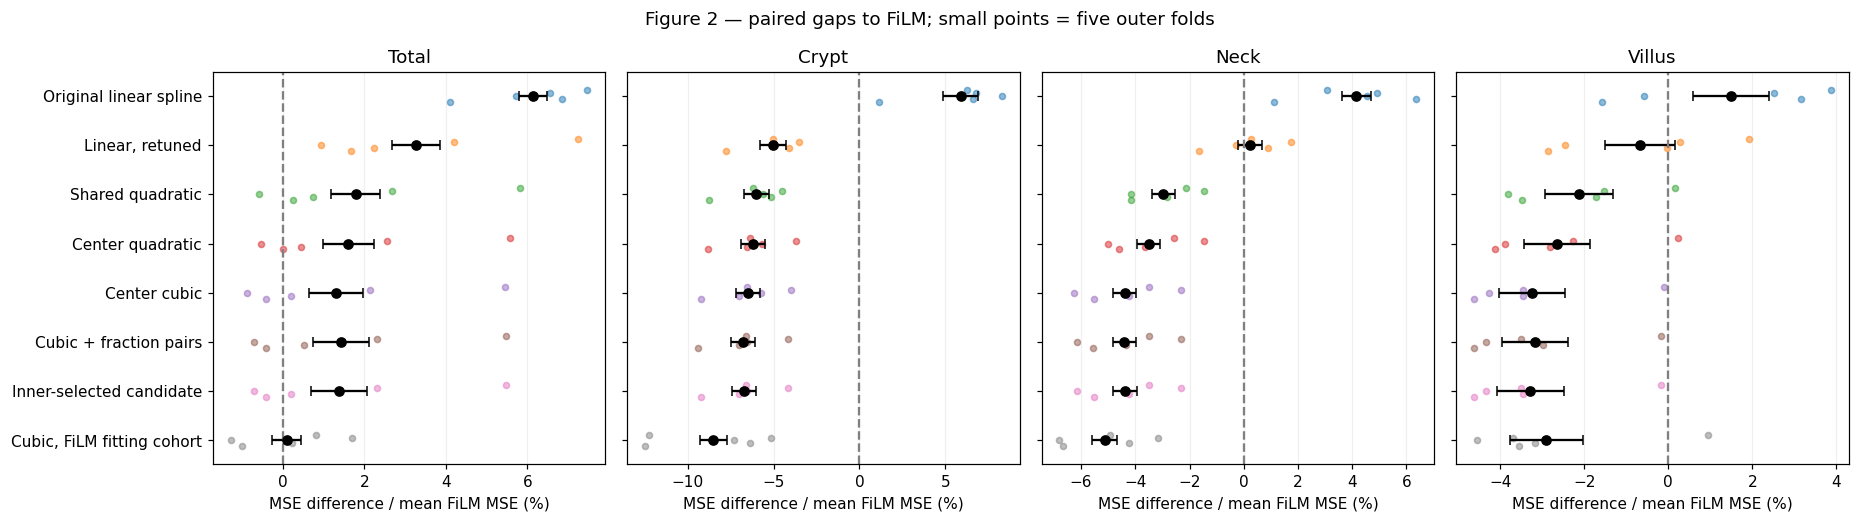

In [23]:
reference_scores = scores_df[scores_df.name=='FiLM'][['fold','organoid_str','region','mse']].rename(columns={'mse':'film_mse'})
paired = scores_df[scores_df.name!='FiLM'].merge(reference_scores,on=['fold','organoid_str','region'],validate='many_to_one')
paired['difference'] = paired.mse-paired.film_mse
paired.to_csv(RUN_DIR/'paired_differences.csv',index=False)
gap = organoid_mse_summary(paired,['name','region'],value='difference')
means = reference_scores.groupby('region').film_mse.mean()
gap['percent_of_film'] = 100*gap['mean']/gap.region.map(means)
gap.to_csv(RUN_DIR/'paired_summary.csv',index=False)
fig,axes = plt.subplots(1,len(REGIONS),figsize=(17,4.8),sharey=True)
for ax,region in zip(axes,REGIONS):
    part = gap[gap.region==region].set_index('name').reindex(order[:-1])
    scale = 100/means[region]
    ax.errorbar(part['mean']*scale,np.arange(len(part)),xerr=part['sem']*scale,fmt='o',capsize=3,color='black')
    for j,name in enumerate(order[:-1]):
        fold_gap = paired[(paired.name==name)&(paired.region==region)].groupby('fold').difference.mean()*scale
        ax.scatter(fold_gap,np.full(len(fold_gap),j)+np.linspace(-.12,.12,len(fold_gap)),s=16,alpha=.5)
    ax.axvline(0,color='gray',ls='--')
    ax.set(title=region.capitalize(),xlabel='MSE difference / mean FiLM MSE (%)')
    ax.grid(axis='x',alpha=.2)
axes[0].set_yticks(np.arange(len(order)-1),[labels[n] for n in order[:-1]])
axes[0].invert_yaxis()
fig.suptitle('Figure 2 — paired gaps to FiLM; small points = five outer folds')
fig.tight_layout()
fig.savefig(RUN_DIR/'02_paired_gaps.png',dpi=170,bbox_inches='tight')
plt.show()

## Validation error across organoid sizes

Figure 3 displays total MSE by observed N for the original spline, the candidate selected inside each fold, and FiLM. Bin boundaries are descriptive only. Shaded bands are one SEM across organoids in the bin, and the lower panel reports support. These are actual held-out predictions at observed size, not counterfactual N sweeps. All per-candidate, per-region and per-fold scores remain available in the CSV files.

Models, exact fold data, penalty trials, benchmark tables and figures: /home/fmoller/Projects/LearningOrganoids/GraphNN/training_results/fate_fraction_benchmark/nonlinear_fractions_20260924_153659


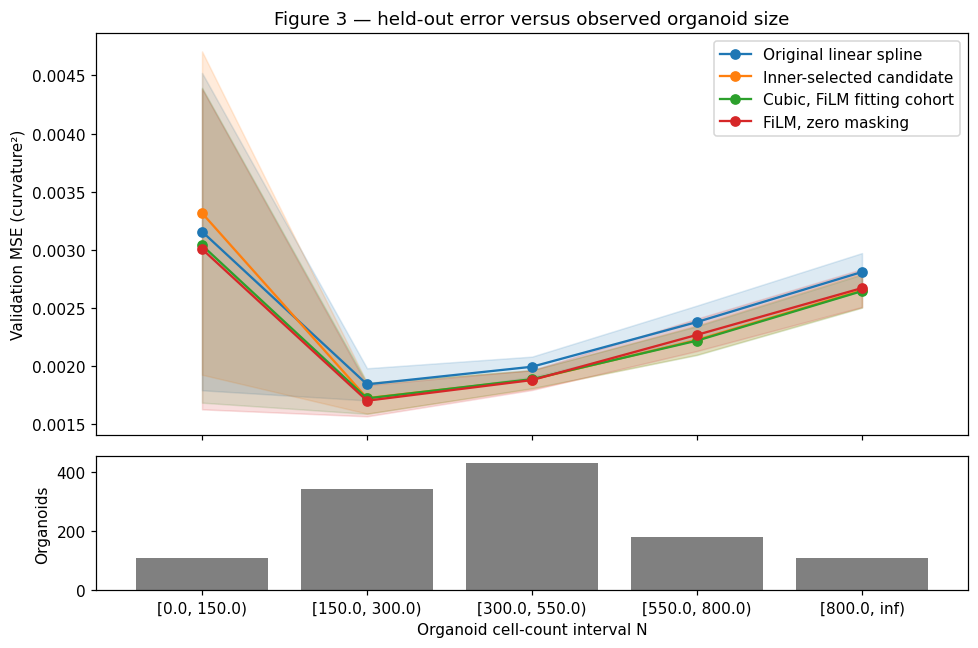

In [24]:
total = scores_df[scores_df.region=='total'].copy()
total['N_bin'] = pd.cut(total.n_cells,N_BINS,right=False)
size_summary = organoid_mse_summary(total,['name','N_bin'])
size_summary.to_csv(RUN_DIR/'mse_by_size.csv',index=False)
fig,(ax,support_ax) = plt.subplots(2,1,figsize=(9,6),sharex=True,gridspec_kw={'height_ratios':[3,1]})
for name in ['original_spline','inner_selected','cubic_matched_fit','FiLM']:
    curve = size_summary[size_summary.name==name].sort_values('N_bin')
    x = np.arange(len(curve))
    line, = ax.plot(x,curve['mean'],'o-',label=labels[name])
    ax.fill_between(x,curve['mean']-curve['sem'],curve['mean']+curve['sem'],alpha=.15,color=line.get_color())
curve = size_summary[size_summary.name=='FiLM'].sort_values('N_bin')
support_ax.bar(np.arange(len(curve)),curve['count'],color='gray')
support_ax.set_xticks(np.arange(len(curve)),[str(b) for b in curve.N_bin])
ax.set(title='Figure 3 — held-out error versus observed organoid size',ylabel='Validation MSE (curvature²)')
ax.legend()
support_ax.set(xlabel='Organoid cell-count interval N',ylabel='Organoids')
fig.tight_layout()
fig.savefig(RUN_DIR/'03_mse_by_size.png',dpi=170,bbox_inches='tight')
plt.show()
print('Models, exact fold data, penalty trials, benchmark tables and figures:',RUN_DIR)